This file acts as a playground to determine f.e. the ideal Interval for the Analysis

In [1]:

Patient = "P036" #"P015/P015_S01_D2024-07-06"
run = "S01"
date = "2025-11-06"

In [2]:
import importlib
import analyzer
importlib.reload(analyzer)
from analyzer import Analyzer
import matplotlib.pyplot as plt
import pandas as pd
import re
import os
import json
import numpy as np




analysis = Analyzer(
        filename=f"Data/{Patient}/{Patient}_{run}_D{date}.tdms",
        add_filename=f"Data/{Patient}/{Patient}_{run}_D{date}_addCh.tdms",
        log_file_path=f"Data/{Patient}/QZFM_log_file.txt",
        sensor_channels_to_exclude={"Brustlage": ["C1_x", "C1_y", "YP_y", "YP_z", "YQ_y", "YQ_z", "OT_y", "OT_z", "NL_x", "OX_x", "OX_y"]},
        #model_checkpoint_dir=f"MCG_segmentation/trained_models/UNet_1D_900k",
    )

key = "Brustlage"  # "Bauchlage", "Brustlage", "Rechtslage", "LinksLage"
(x_data, y_data, z_data), time, single_run = analysis.prepare_data(key, apply_default_filter=True, align=False, plot_alignment=True)


2025-11-16 17:16:55,686 - INFO - Using device: mps
2025-11-16 17:16:55,690 - INFO - Using device: mps
2025-11-16 17:16:56,320 - INFO - Loaded primary TDMS file: Data/P036/P036_S01_D2025-11-06.tdms
2025-11-16 17:16:56,591 - INFO - Loaded additional TDMS file: Data/P036/P036_S01_D2025-11-06_addCh.tdms
2025-11-16 17:16:56,592 - INFO - Loaded sensor log file: Data/P036/QZFM_log_file.txt
2025-11-16 17:16:56,592 - INFO - Available runs: Brustlage, Rueckenlage, Noise
2025-11-16 17:16:57,019 - INFO - Model loaded successfully from MCG_segmentation/trained_models/UNet_1D_15M/checkpoints/acm_study_checkpoint/model.pth
2025-11-16 17:16:58,867 - INFO - Resampling data from 1000Hz to 250Hz. Target length: 72508, Original length: 290032 samples.


# Find fitting intervall

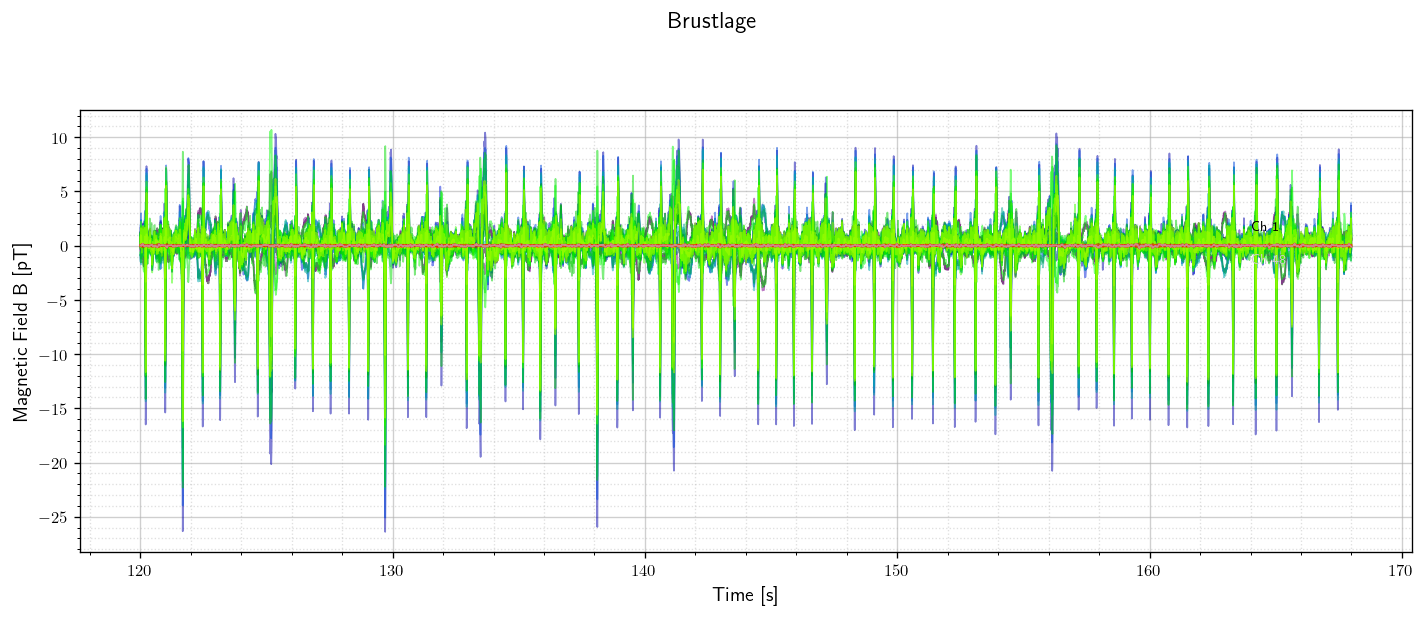

In [3]:
intervall_start = 30000
intervall_end = 42000


analysis.butterfly_plot(single_run[: :, intervall_start:intervall_end], time[intervall_start:intervall_end], single_run.shape[0], "Brustlage")

## Apply ICA filtering 

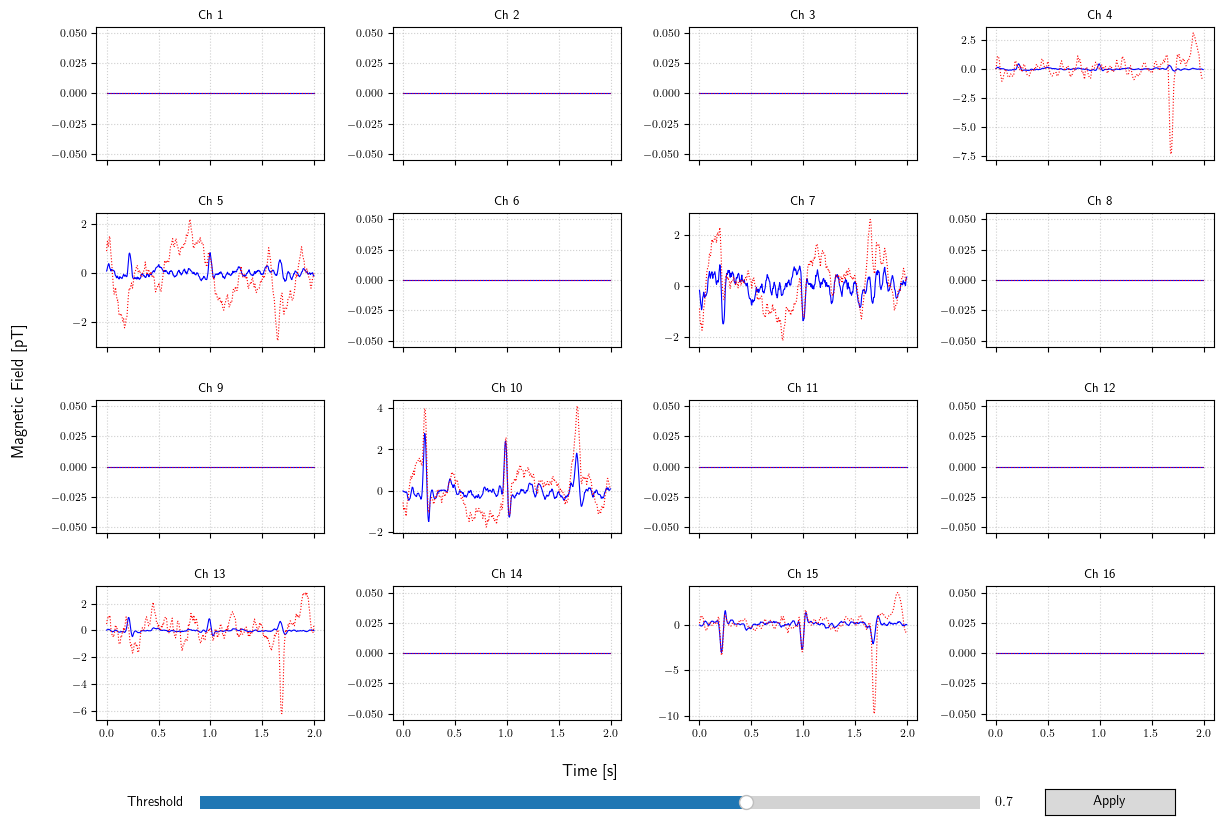

/Volumes/Riesenspeicher/Projekte/Bachelor/Bachelorarbeit/venv/lib/python3.11/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


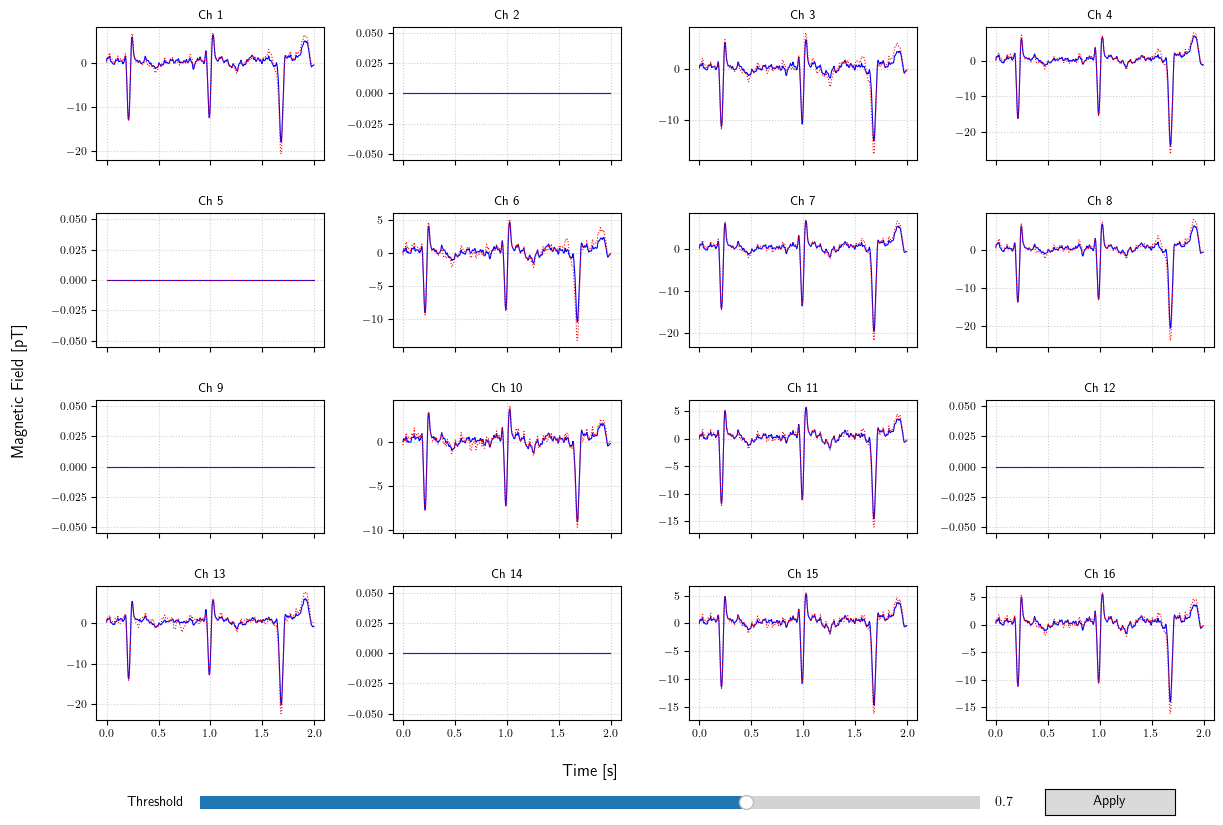

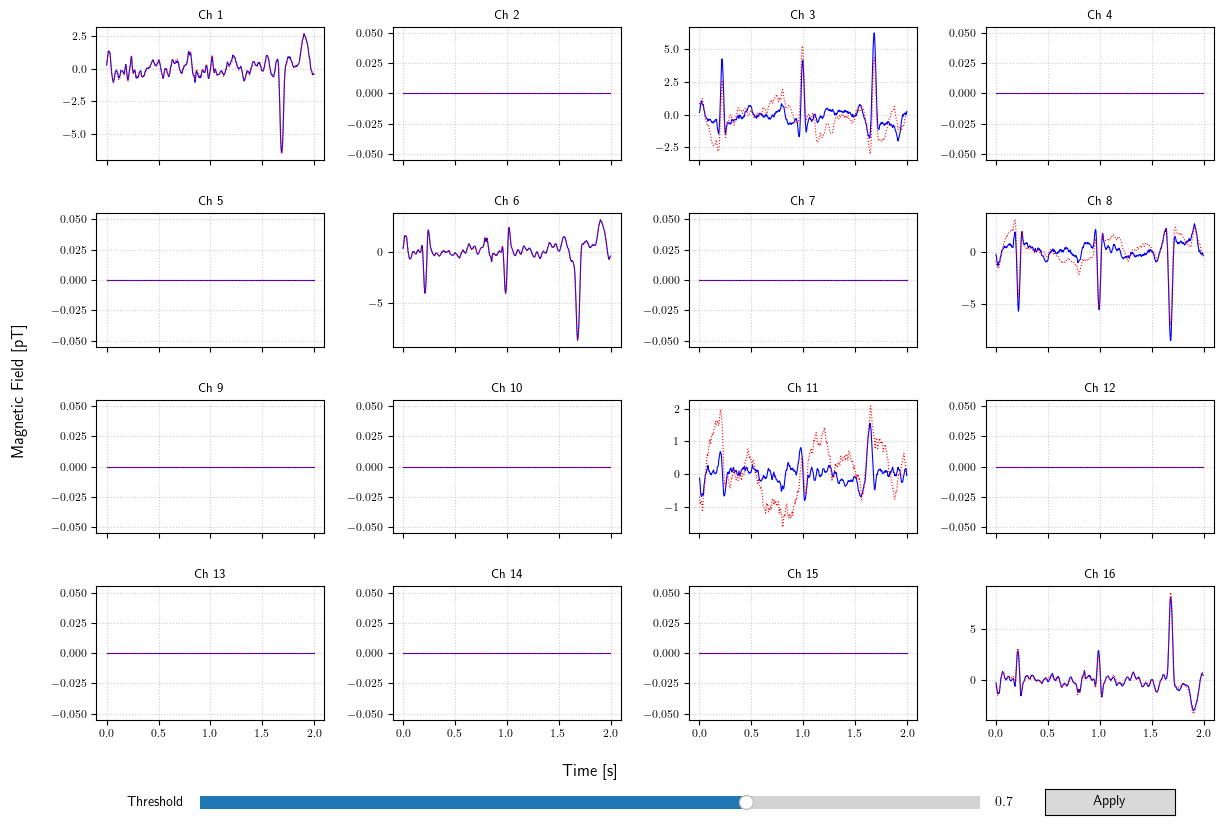

In [4]:


x_data_intervall = x_data[:, :, intervall_start:intervall_end]
y_data_intervall = y_data[:, :, intervall_start:intervall_end]
z_data_intervall = z_data[:, :, intervall_start:intervall_end]
time_intervall = time[intervall_start:intervall_end]
single_run_intervall = single_run[:, intervall_start:intervall_end]


#analysis.plot4x4(z_data[:, :, 250:1250], time[250:1250], name="z_data")

x_data_filtered, _, _, _ = analysis.ICA_filter(x_data_intervall, heart_beat_score_threshold=0.70, plot_result=True)
y_data_filtered, ica_components, _, _ = analysis.ICA_filter(y_data_intervall, heart_beat_score_threshold=0.70, plot_result=True)
z_data_filtered, _, _, _ = analysis.ICA_filter(z_data_intervall, heart_beat_score_threshold=0.70, plot_result=True)

#print(ica_components.shape)
#analysis.plot_sensor_matrix(ica_components[:, :500].reshape(4, 4, -1), time_intervall[:500], name="ica_components")

Improve Windowing

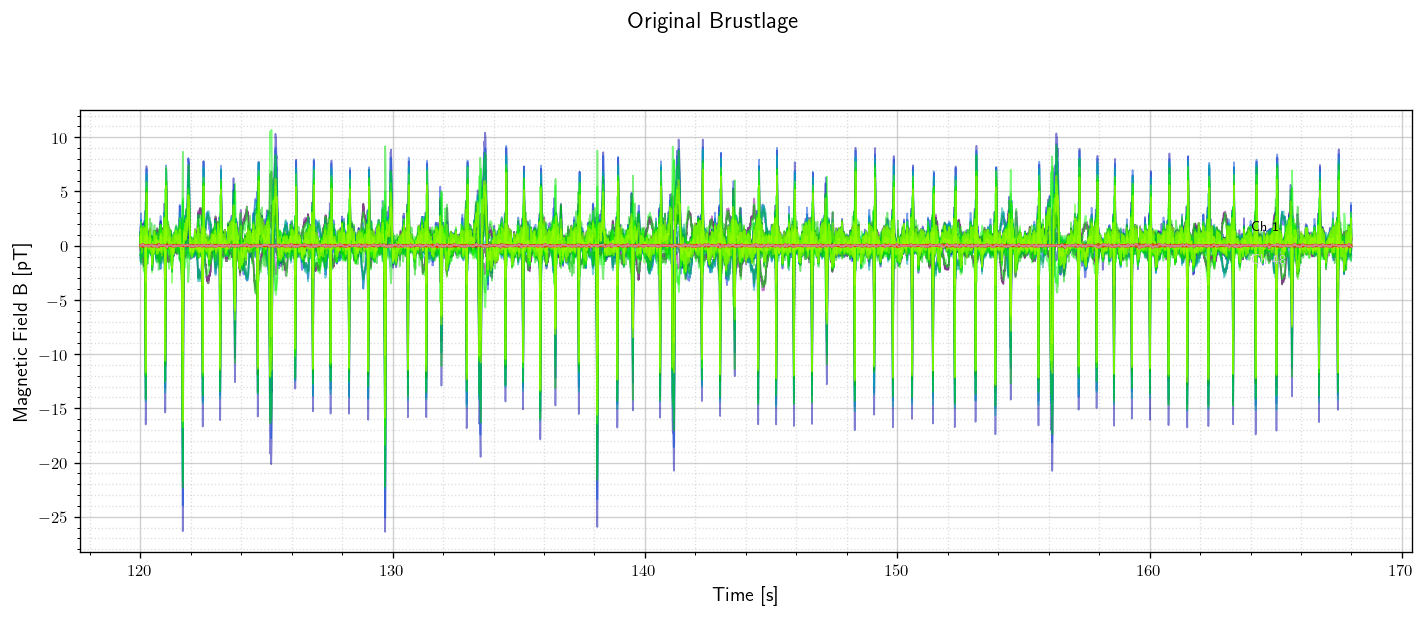


Channel Selection Results:
Channel   Conf        P-Wave %    QRS %       T-Wave %    Plausibility   Final Score 
-------------------------------------------------------------------------------------
1         0.6986      2.32        11.12       18.26       0.6376         0.6864      
2         0.7955      8.65        16.19       17.87       0.8935         0.8151      
3         0.7624      2.07        14.36       20.58       0.6276         0.7355      
4         0.7890      8.87        15.62       17.84       0.9412         0.8194      
5         0.6915      0.76        9.03        15.58       0.5800         0.6692      
6         0.7929      8.05        15.66       17.93       0.9382         0.8220      
7         0.6782      0.43        11.21       17.03       0.5690         0.6563      
8         0.8034      7.51        16.45       18.14       0.8374         0.8102      
9         0.6597      0.24        5.27        3.89        0.3165         0.5910      
10        0.6766      0.00

2025-11-16 17:17:18,581 - INFO - Heart Rate: 77.47 bpm
2025-11-16 17:17:18,585 - INFO - Heart Rate Variability (SDNN): 153.33 ms
2025-11-16 17:17:18,586 - INFO - Number of detected peaks: 62
2025-11-16 17:17:18,586 - INFO - Number of plausible RR intervals used: 61


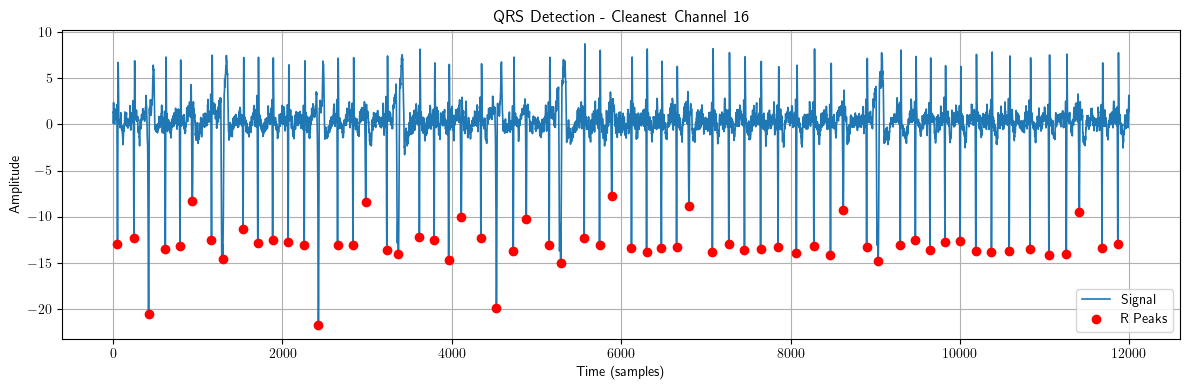

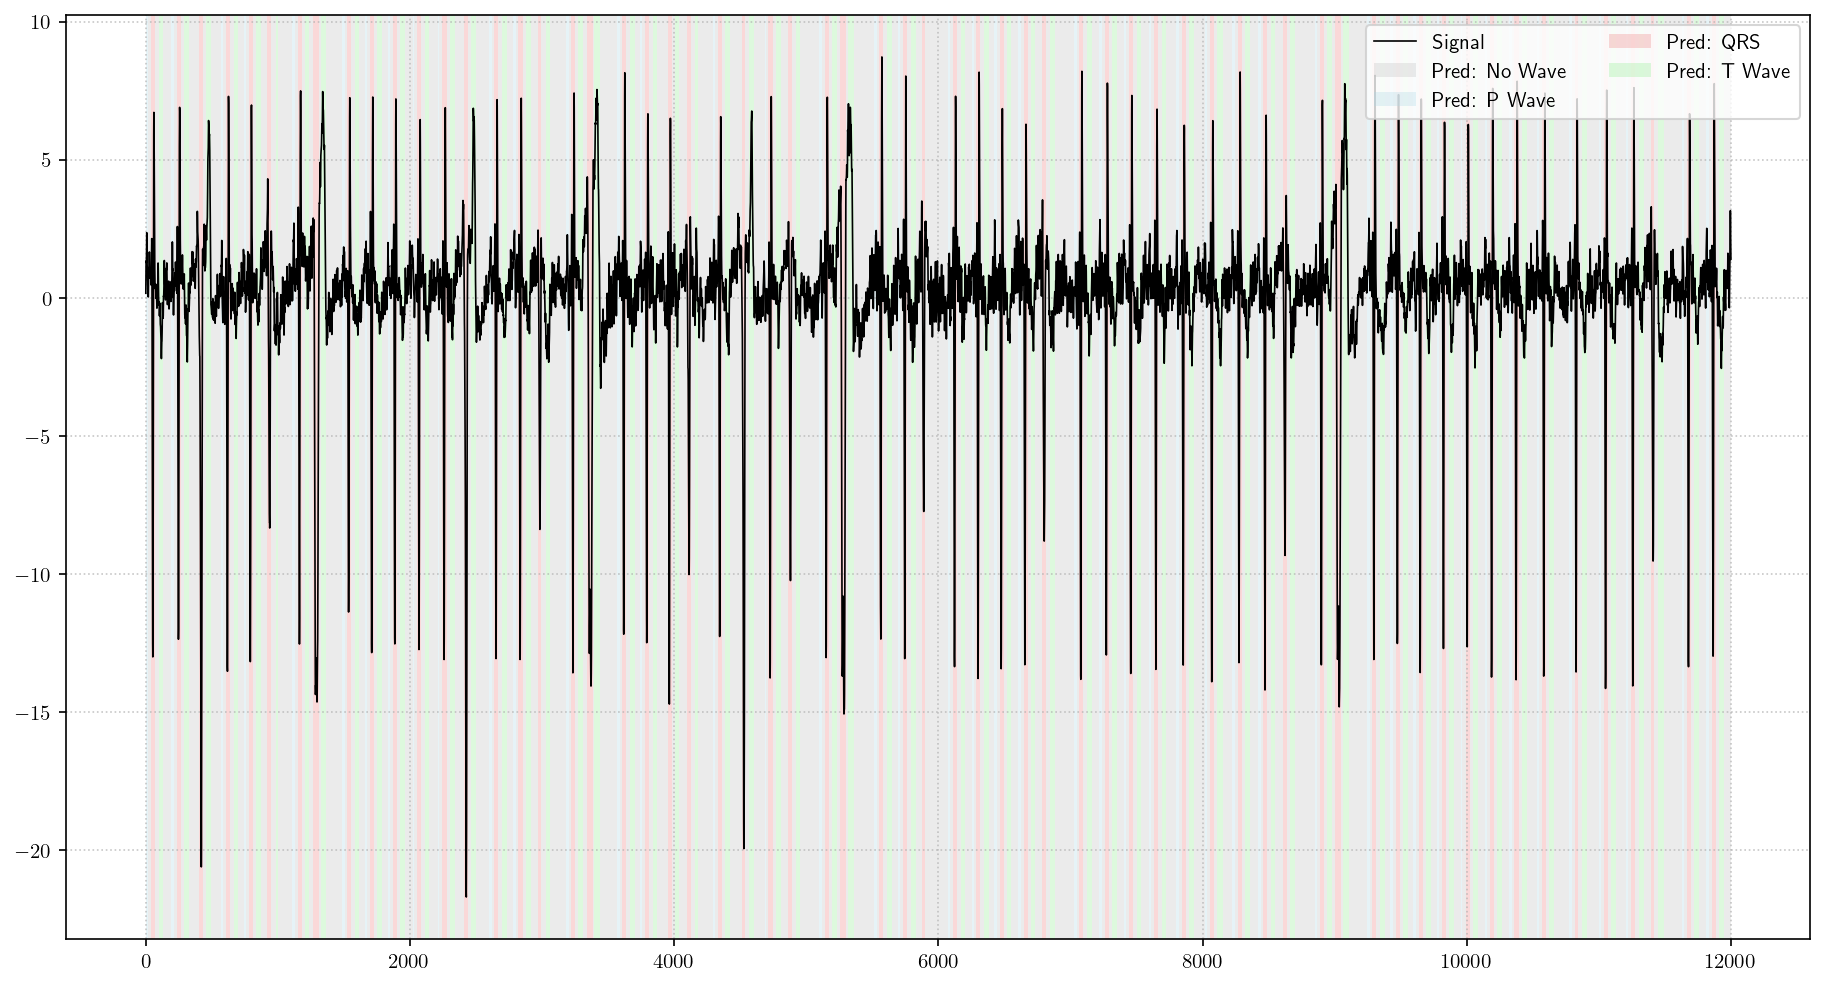

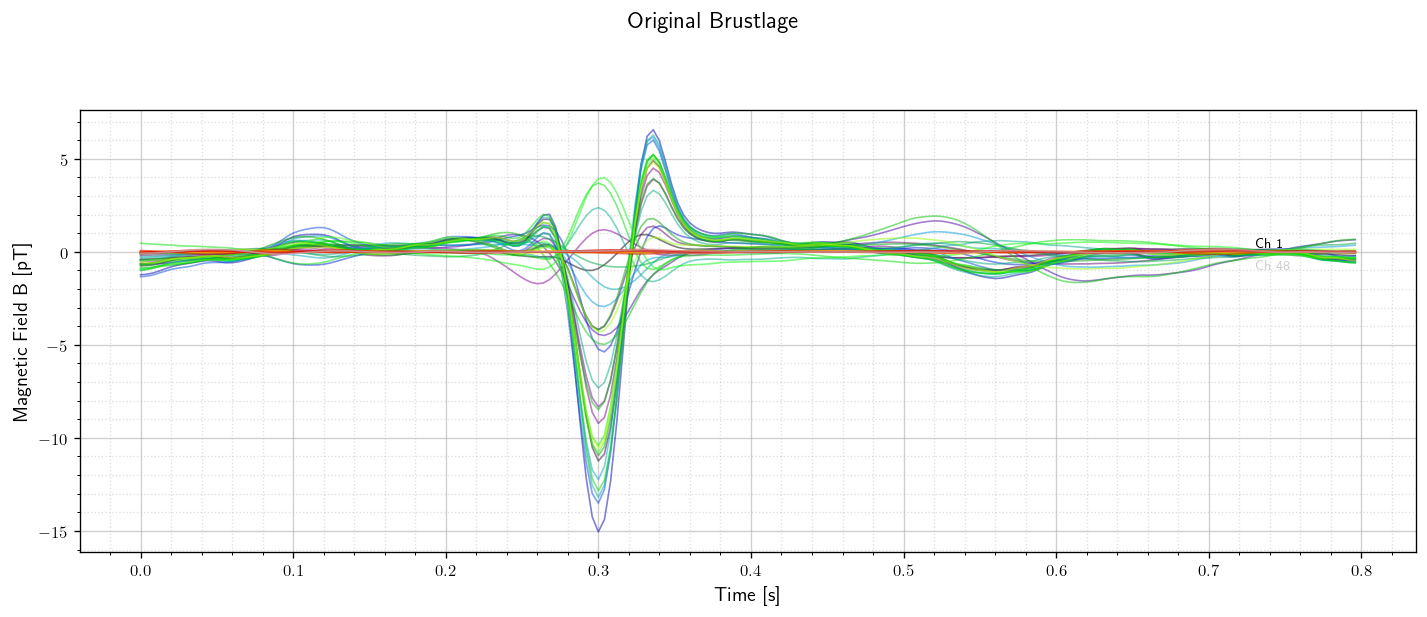

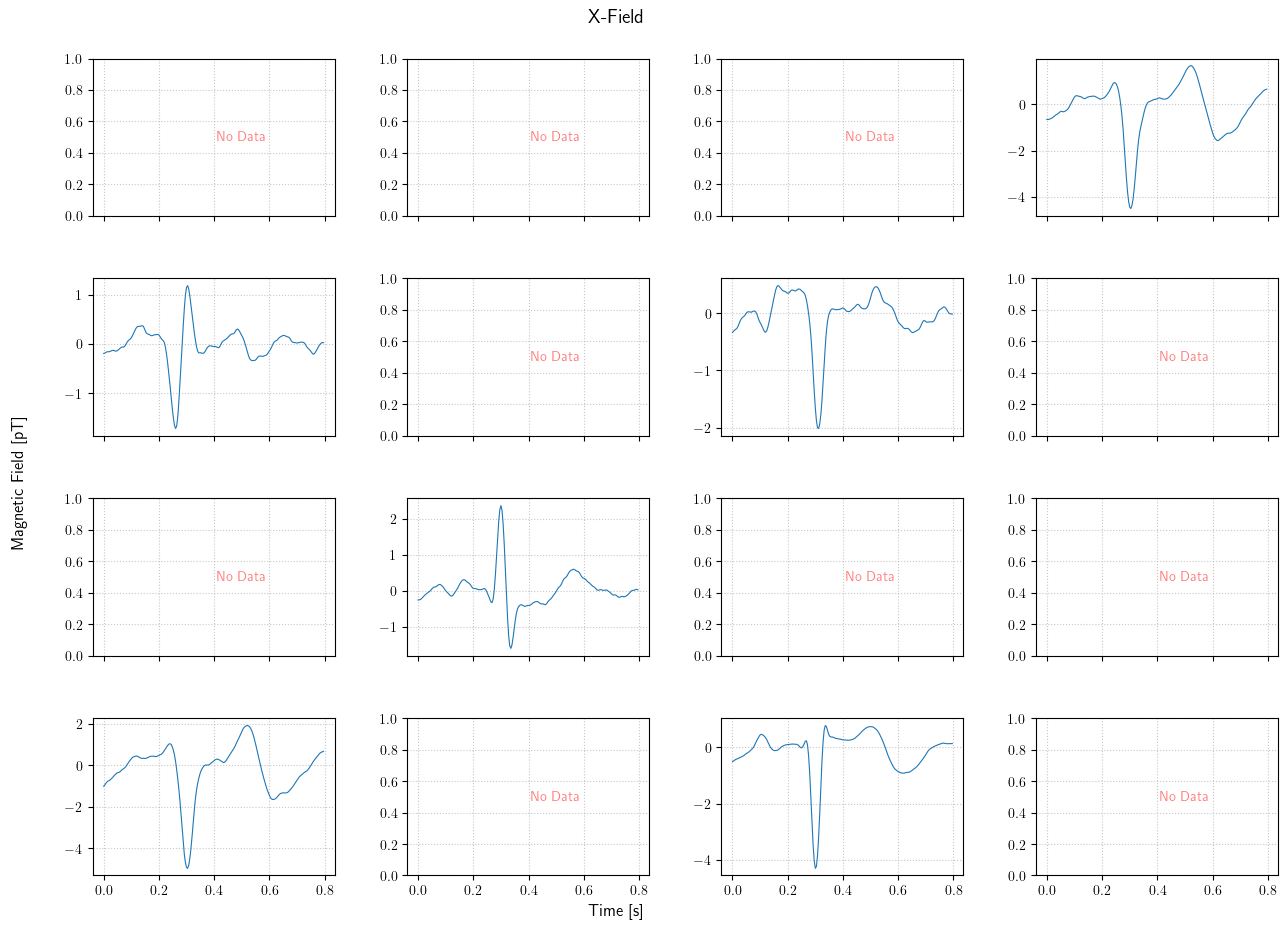

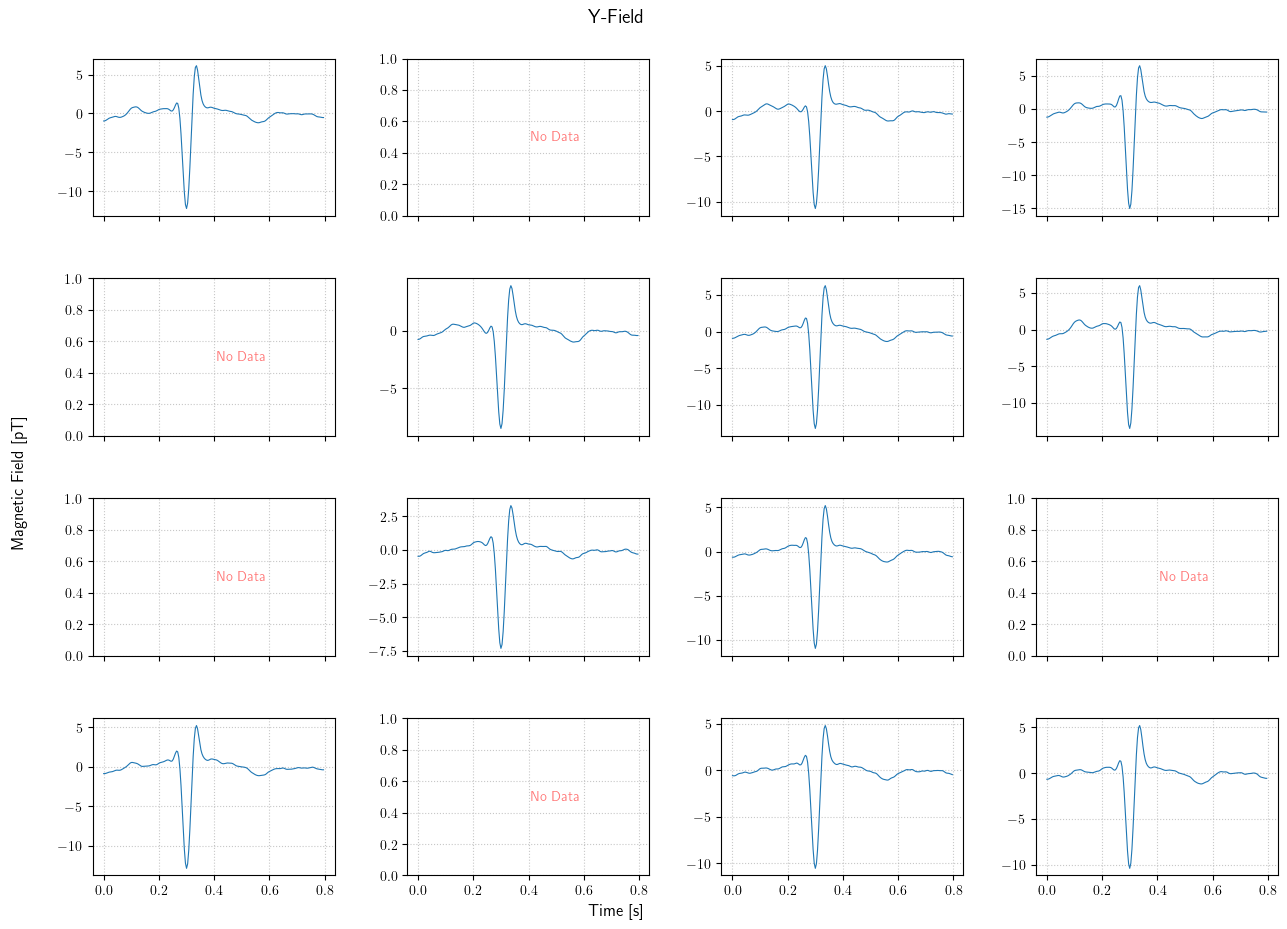

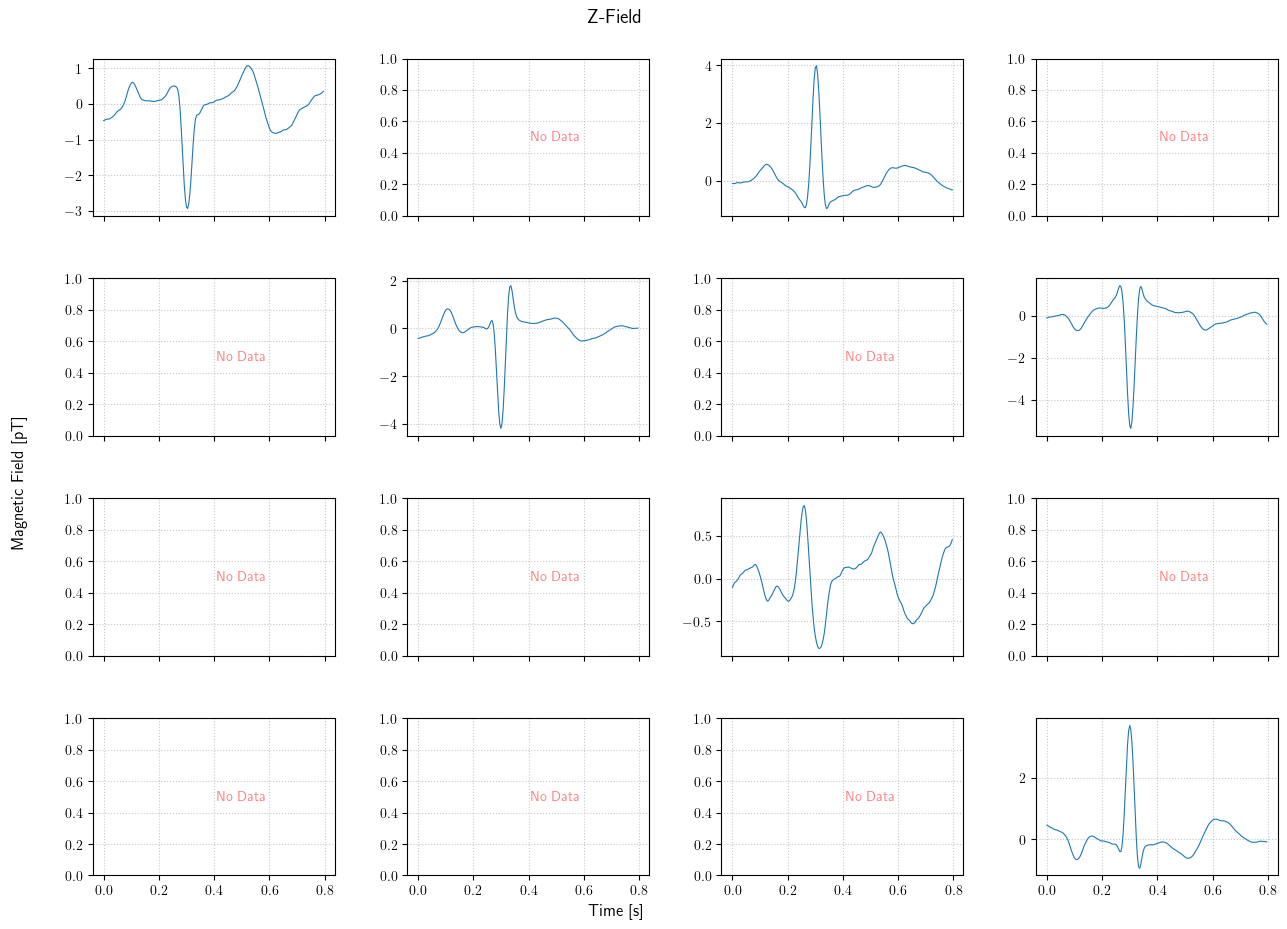

In [5]:
single_run_filtered = single_run_intervall#analysis.invert_field_directions(x_data_filtered, y_data_filtered, z_data_filtered, key, 48)


analysis.butterfly_plot(single_run_filtered, time_intervall, 48, f"Original {key}")


analysis.find_cleanest_channel(single_run_filtered)

# use cleanest channel for peak detection
peak_positions, ch, labels, _, _ = analysis.detect_qrs_complex_peaks_cleanest_channel(single_run_filtered, print_heart_rate=True, confidence_threshold=0.7, confidence_weight=1, plausibility_weight=0)
if peak_positions is not None and len(peak_positions) > 0:
    plt.figure(figsize=(12, 4))
    plt.plot(single_run_filtered[ch, :], label='Signal', linewidth=1.2)
    #plt.plot(resampled_data[ch, :], label='Signal', linewidth=1.2)
    plt.plot(peak_positions, single_run_filtered[ch, peak_positions], "ro", markersize=6, label='R Peaks')
    plt.title(f"QRS Detection - Cleanest Channel {ch + 1}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No R peaks detected or `peak_positions` is empty.")
analysis.plot_segmented_signal(single_run_filtered[ch, :], labels[ch, :])


# window averaging
avg_channels, time_window = analysis.avg_window(single_run_filtered, peak_positions, window_left=0.3, window_right=0.5)
analysis.butterfly_plot(avg_channels, time_window, 48, f"Original {key}")


x_data_window, y_data_window, z_data_window = analysis.get_field_directions(avg_channels, key)

analysis.plot_sensor_matrix(x_data_window, time_window, name="X-Field")
analysis.plot_sensor_matrix(y_data_window, time_window, name="Y-Field")
analysis.plot_sensor_matrix(z_data_window, time_window, name="Z-Field")



## ICD Analysis

In [6]:
patient = "P035" #"P015/P015_S01_D2024-07-06"
date = "2025-06-26"
run = "S01"

log_file_path = f"Data/{patient}/QZFM_log_file.txt"
add_filename = f"Data/{patient}/{patient}_{run}_D{date}_addCh.tdms"
file_name = f"Data/{patient}/{patient}_{run}_D{date}.tdms"

analysis = Analyzer(
        filename=file_name,
        add_filename=add_filename,
        log_file_path=log_file_path,
        model_checkpoint_dir="MCG_segmentation/trained_models/MCGSegmentator_s",
        sensor_channels_to_exclude={}
    )

(x_data, y_data, z_data), time, single_run = analysis.prepare_data("Brustlage", apply_default_filter=True, plot_alignment=False)

single_run = single_run[:, 38000:40000]
time = time[38000:40000]

analysis.butterfly_plot(single_run, time, 16, f"Original")


# Example: Apply LSD plotting to QRS-aligned average data
channels_to_plot = list(range(single_run.shape[0]))  # or a subset if too many

# Call your function
analysis.plot_lsd_multichannel(
    data=single_run,
    channels=channels_to_plot,
)



2025-11-16 17:17:25,163 - INFO - Loaded primary TDMS file: Data/P035/P035_S01_D2025-06-26.tdms
2025-11-16 17:17:25,526 - INFO - Loaded additional TDMS file: Data/P035/P035_S01_D2025-06-26_addCh.tdms
2025-11-16 17:17:25,527 - INFO - Loaded sensor log file: Data/P035/QZFM_log_file.txt
2025-11-16 17:17:25,528 - INFO - Available runs: Brustlage, Rueckenlage, Noise


FileNotFoundError: Model file 'model.pth' not found in MCG_segmentation/trained_models/MCGSegmentator_s